In [ ]:
Milestone 1: Profiling Analysis
cProfile Table (Summary)

| ncalls | tottime | cumtime | function |
| :--- | :--- | :--- | :--- |
| 1 | 0.923 | 1.126 | `mandelbrot_naive` |
| 5,698,796 | 0.204 | 0.204 | `built-in abs` |
| 1 | 0.099 | 0.099 | `mandelbrot_numpy` |

--- Profile for naive_profile.prof ---
Thu Feb 26 14:31:51 2026    naive_profile.prof

         5698827 function calls in 1.126 seconds

   Ordered by: cumulative time
   List reduced from 19 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    1.126    1.126 {built-in method builtins.exec}
        1    0.000    0.000    1.126    1.126 <string>:1(<module>)
        1    0.923    0.923    1.126    1.126 /Users/akshara_sarun/school-repo/mandelbrot_functions.py:5(mandelbrot_naive)
  5698796    0.204    0.000    0.204    0.000 {built-in method builtins.abs}
        1    0.000    0.000    0.000    0.000 {built-in method numpy.zeros}
        2    0.000    0.000    0.000    0.000 /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/function_base.py:25(linspace)
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
        2    0.000    0.000    0.000    0.000 {built-in method numpy.arange}
        2    0.000    0.000    0.000    0.000 /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/numeric.py:1927(isscalar)
        2    0.000    0.000    0.000    0.000 {method 'reshape' of 'numpy.ndarray' objects}



--- Profile for numpy_profile.prof ---
Thu Feb 26 14:31:51 2026    numpy_profile.prof

         74 function calls in 0.100 seconds

   Ordered by: cumulative time
   List reduced from 39 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.100    0.100 {built-in method builtins.exec}
        1    0.000    0.000    0.100    0.100 <string>:1(<module>)
        1    0.099    0.099    0.099    0.099 /Users/akshara_sarun/school-repo/mandelbrot_functions.py:23(mandelbrot_numpy)
        1    0.000    0.000    0.000    0.000 /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:5117(meshgrid)
        3    0.000    0.000    0.000    0.000 /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:5263(<genexpr>)
        1    0.000    0.000    0.000    0.000 /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/numeric.py:64(zeros_like)
        2    0.000    0.000    0.000    0.000 {method 'copy' of 'numpy.ndarray' objects}
        2    0.000    0.000    0.000    0.000 {built-in method numpy.zeros}
        2    0.000    0.000    0.000    0.000 /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/function_base.py:25(linspace)
        1    0.000    0.000    0.000    0.000 /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_stride_tricks_impl.py:481(broadcast_arrays)



1. Which function takes most total time?
mandelbrot_naive version take the most cumulative time  1.126 seconds. In mandelbrot_numpy only taken 0.100s



2. Are there functions called surprisingly many times?
yes.In naive built-in method builtins.abs function called 5698796 times, its a significant overhead

3. How does the NumPy profile compare to naive?
Numpy is obviously effiecient. Total function call just reduced to only 74, while in naive it take millions. 11.26 times speedup (1.126/0.100 = 11.26). In naive method python talk to CPU 5698796 times to ask for an abs() aclculation which is overhead take more time than the actual math, while in Numpy python talk to only a few times 

4. Where does NumPy spend its time?
Numpy spends all its time  (0.099s) inside single mandelbrot_numpy function bacuase of the C-compiled array operation not becuase of the python level subclass

MP1
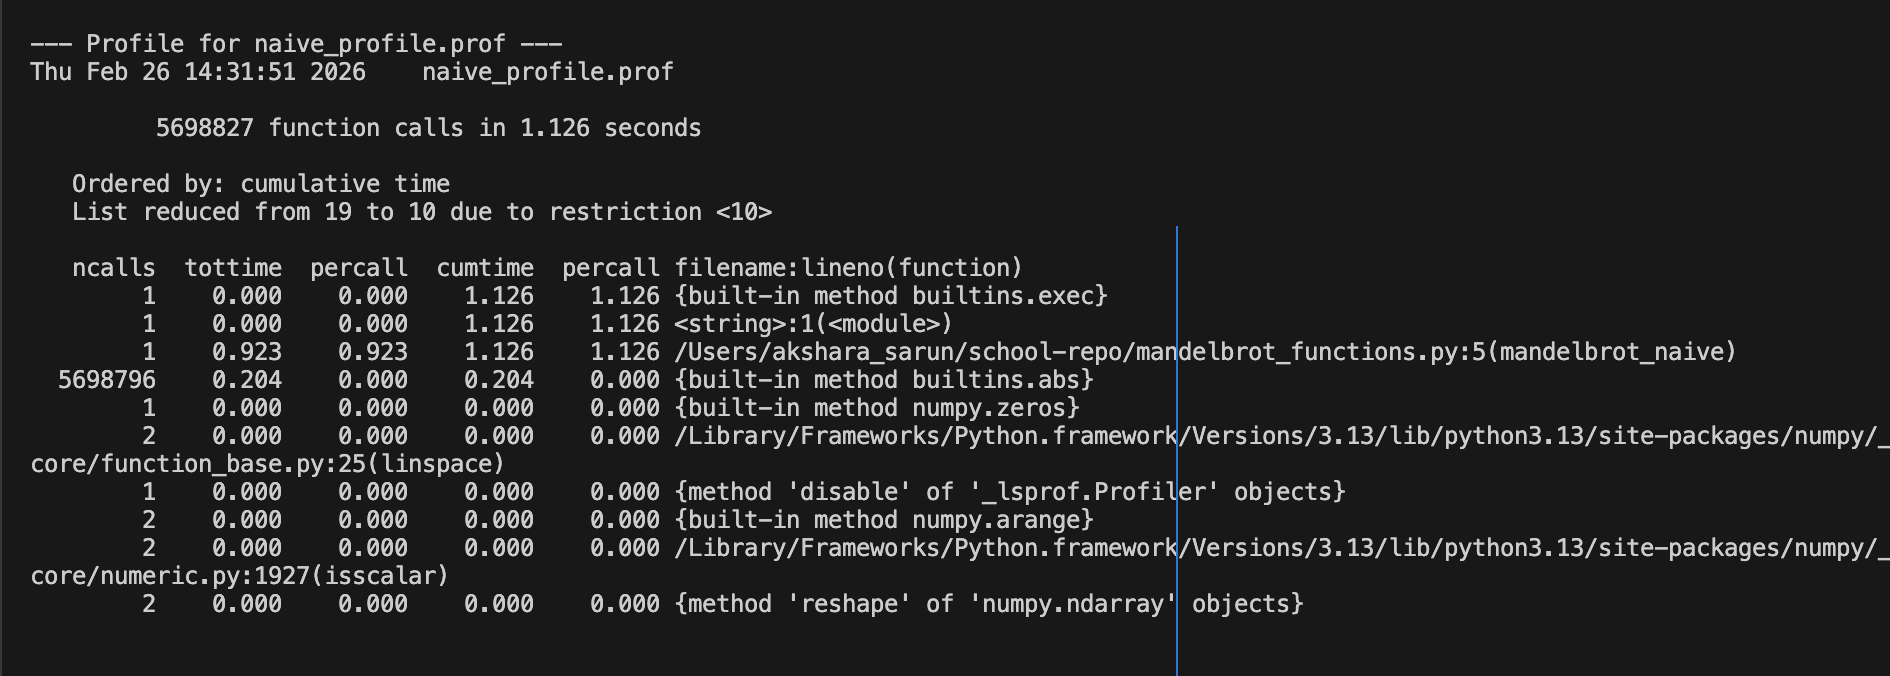
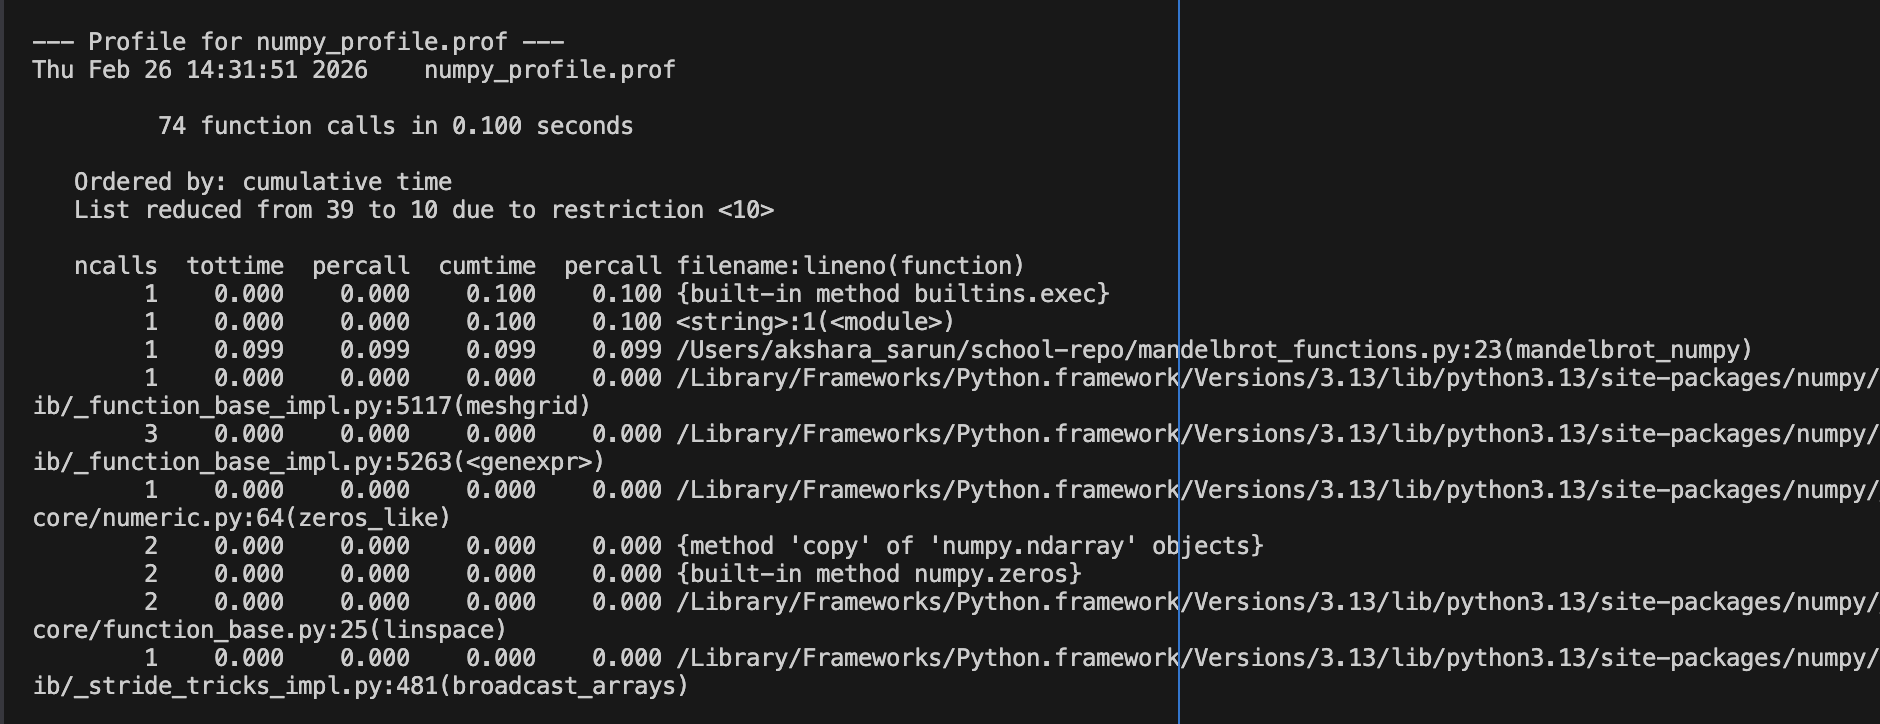


1. cProfile on naive vs NumPy: How many functions appear in each profile? What does
this difference tell you about where the work actually happens?

cProfile on naive executed 5698827 function calls, numpy calls only 74 functions
In naive version the task is fragmented into millions of individual python level calls(like the abs()) which created interpreter overhead. In numpy work is vectorised python gives a large block of data to a underlying C-engine that process all in one highly efficient call.

2. line profiler on naive: Which lines dominate runtime? What fraction of total time is
spent in the inner loop?

The most time taken lines are if abs(z) <= 2 ; z = z*z + c; m[i, j] += 1 
22.5% + 20.2% + 35.3% = 78% of total time spend in these three lines
These lines are executed  5.4 million times each, proving the code is compute-bound by loop overhead.


3. Based on your profiling results: why is NumPy faster than naive Python?

because Numpy minimises the Python Interpreter Overhead. Instead python managing seperate functin calls for every pixel Numpy perform this operation in a contiguos memory (one single, unbrocken block and right next to each other) using optimised code. 

4. What would you need to change to make the naive version faster? (hint: what does
line profiler tell you about the inner loop?)

since the lines, abs(z) <= 2 ; z = z*z + c; m[i, j] += 1 are hiting 5.4 million times we should find a solution to fix that area , we need to find a way  running the lines without python checking the type and running the logic every single time 




Milestone 2:

Total time: 3.10146 s
File: mandelbrot_functions.py
Function: mandelbrot_naive at line 5

Line #      Hits         Time  Per Hit   % Time  Line Contents
==============================================================
     5                                           @profile # Add this decorator
     6                                           def mandelbrot_naive(x_min, x_max, y_min, y_max, width, height, max_iter=100):
     7         1         30.0     30.0      0.0      x = np.linspace(x_min, x_max, width)
     8         1         13.0     13.0      0.0      y = np.linspace(y_min, y_max, height)
     9         1        136.0    136.0      0.0      m = np.zeros((height, width), dtype=int)
    10                                               
    11       513         55.0      0.1      0.0      for i in range(height):
    12    262656      27268.0      0.1      0.9          for j in range(width):
    13    262144      57534.0      0.2      1.9              c = complex(x[j], y[i])
    14    262144      25874.0      0.1      0.8              z = 0j
    15   5743674     550211.0      0.1     17.7              for n in range(max_iter):
    16   5698796     698081.0      0.1     22.5                  if abs(z) <= 2:
    17   5481530     627485.0      0.1     20.2                      z = z*z + c
    18   5481530    1093457.0      0.2     35.3                      m[i, j] += 1
    19                                                           else:
    20    217266      21307.0      0.1      0.7                      break
    21         1          4.0      4.0      0.0      return m



milestone 3 : 
Approach A and B comparison

Hybrid: 0.724 s
Fully compiled: 0.042 s
Ratio: 17.4x

compare all methods

Starting benchmarks...
Naive: 2.261s
NumPy: 0.418s (5.4x speedup)
Numba: 0.042s (54.2x speedup)


milestone 4

observations
1. There is no significant speed difference between float32 and float64 on my system. The CPU handles both types with similar effieciency for specific task. Also both types images look identical. flot32 version has a maximum difference of 33 . This means some pixels are calculated incorrectly becuase 32 bit is not precise enough to handle the complex mandlebrot iteration.so i prefer 64


![alt text](image.png)

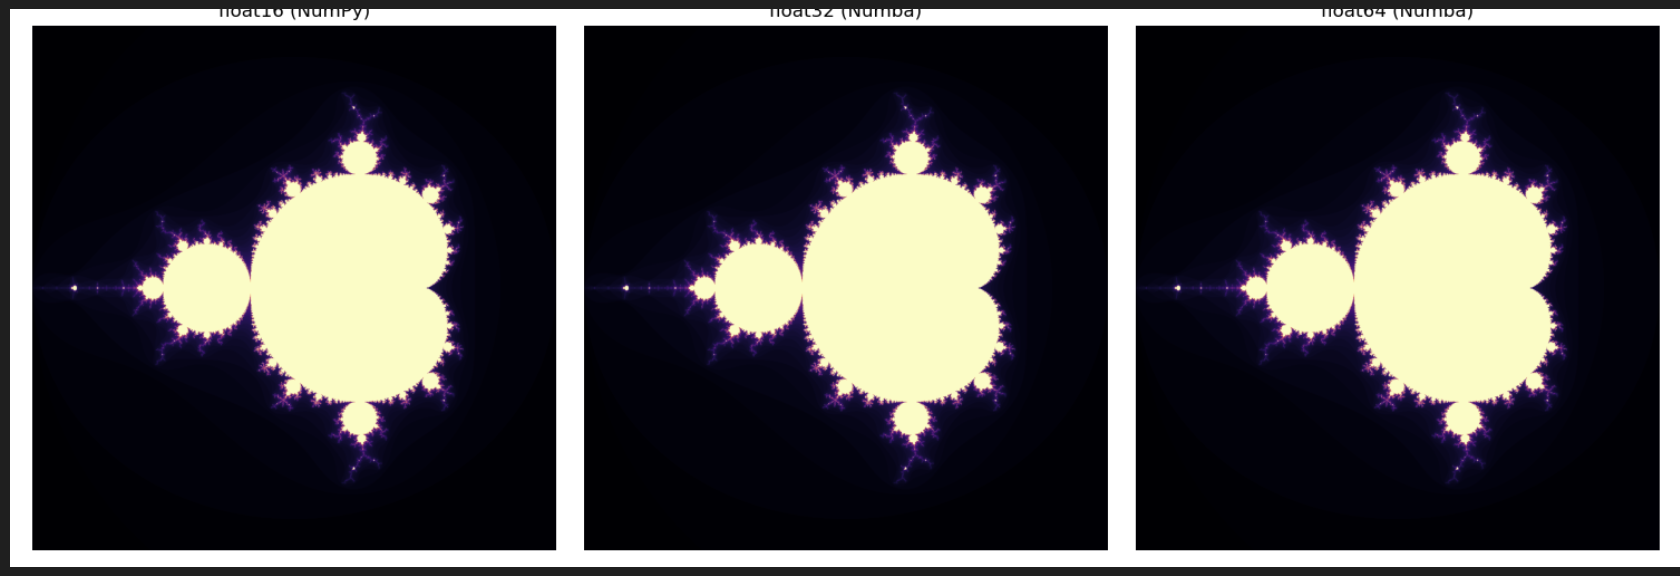
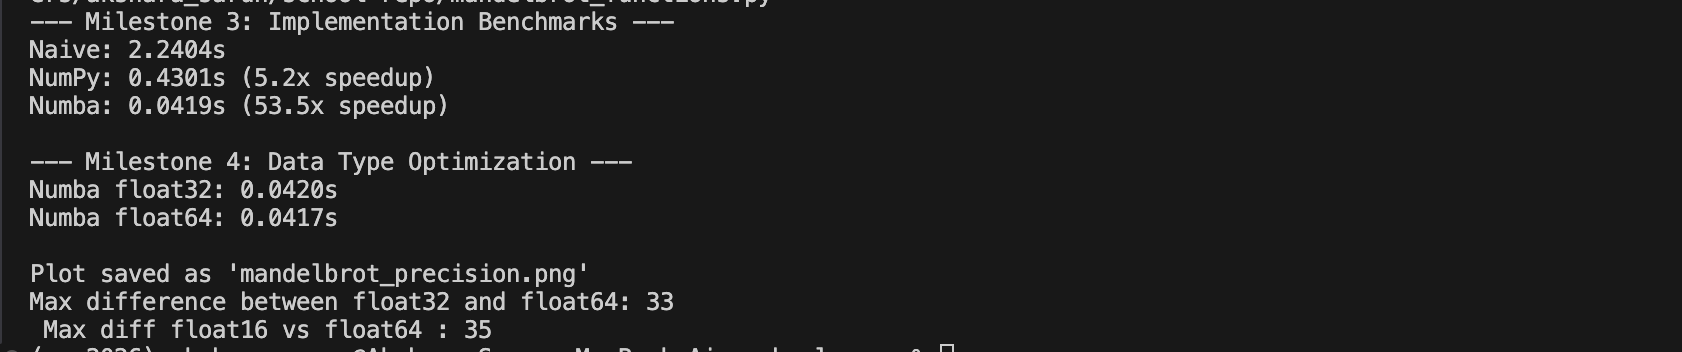